Device: cuda
GPU : Tesla T4
VRAM: 15.6 GB

█████████████████████████████████████████████████████████████████
  STEP 1 — LOAD & PREPARE DATA  (patient-level dual-eye)
█████████████████████████████████████████████████████████████████
CSV shape: (6392, 19)
Images dir: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images
  Patients: 6392 | Missing eyes: 324
  Normalising IQA features...

█████████████████████████████████████████████████████████████████
  STEP 2 — TRAIN–VALIDATION SPLIT
█████████████████████████████████████████████████████████████████
Train: 5439 patients
Val  : 953 patients — overlap=0 ✓

█████████████████████████████████████████████████████████████████
  STEP 0 — CLIP PRECOMPUTATION  (patient-level: avg L+R embeddings)
█████████████████████████████████████████████████████████████████
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 314MiB/s]


  CLIP ViT-B/32 loaded ✓
  Class sim: S[G,O]=0.863  S[N,A]=0.876


/tmp/ipykernel_57/1203066411.py:292: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  labs=torch.tensor([p["label"] for p in batch],dtype=torch.float32,device=device)


  CLIP: 32/6392 patients done...
  CLIP: 352/6392 patients done...
  CLIP: 4192/6392 patients done...
  CLIP: 4512/6392 patients done...
  CLIP: 4832/6392 patients done...
  CLIP: 5152/6392 patients done...
  CLIP: 5472/6392 patients done...
  CLIP: 5792/6392 patients done...
  CLIP: 6112/6392 patients done...
  Computing uncertainty (4 views)...
  Done ✓  low-quality: 97 (1.5%)
  CLIP released ✓
  Prototypes ✓  {'N': 1790, 'D': 1834, 'G': 327, 'C': 348, 'A': 268, 'H': 166, 'M': 268, 'O': 1307}

█████████████████████████████████████████████████████████████████
  STEP 3 — DATA PIPELINE  (patient-level dual-eye + Ben Graham)
█████████████████████████████████████████████████████████████████
Train: 5439 patients  bs=12  dual-eye=✓  BenGraham=✓
Val  : 953 patients   bs=24

█████████████████████████████████████████████████████████████████
  STEP 4 — MODEL: Dual-Eye EfficientNet-B4 + Cross-Eye Attention
█████████████████████████████████████████████████████████████████
pos_weight: [ 2.04  1.97

100%|██████████| 74.5M/74.5M [00:00<00:00, 210MB/s]


Trainable parameters: 20,610,544
  Backbone: EfficientNet-B4 (shared L+R) → 100 patch tokens
  Cross-eye attention: L queries R + R queries L → [B,512]
  Meta+IQA: 64+32 → Fused: 608d
  Resolution: 320×320 with Ben Graham preprocessing

█████████████████████████████████████████████████████████████████
  STEP 5 — PHASE 1: WARM-UP (6 ep, BCE+CLIP-smooth)
█████████████████████████████████████████████████████████████████
  Ep |    Loss     Acc |  ValLoss  ValAcc  MacroF1 |     L1     L2     L3     L6 | LR
─────────────────────────────────────────────────────────────────────────────────────
   1 |  1.1875  0.6422 |   0.9700  0.7215   0.4118 |  1.022  0.012  0.008  0.137 | 1.92e-04
   2 |  1.0184  0.7352 |   0.9216  0.7943   0.4765 |  0.866  0.011  0.005  0.131 | 1.71e-04
   3 |  0.8974  0.7920 |   0.9758  0.7993   0.4856 |  0.749  0.011  0.005  0.127 | 1.39e-04
   4 |  0.8258  0.8251 |   0.9611  0.8257   0.5189 |  0.679  0.012  0.005  0.125 | 1.01e-04
   5 |  0.7650  0.8469 |   0.9770  0.83

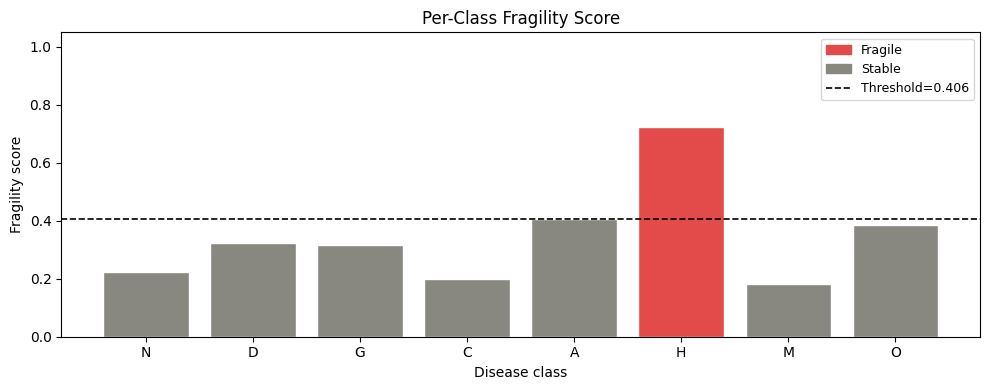

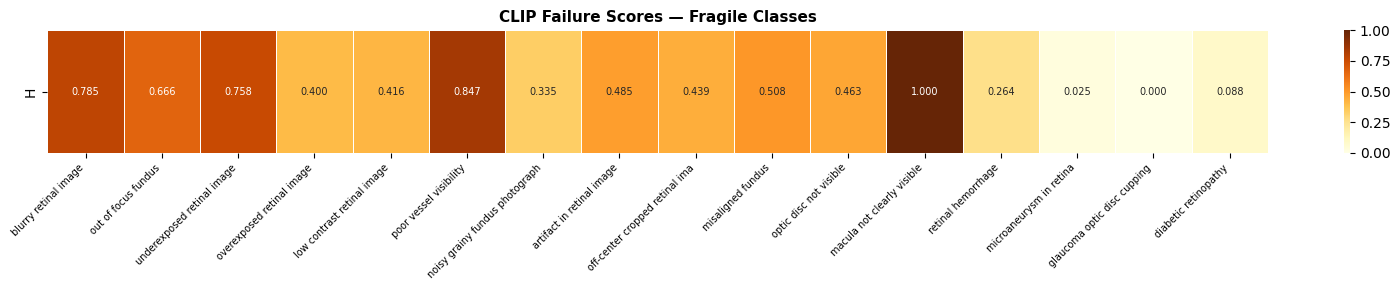

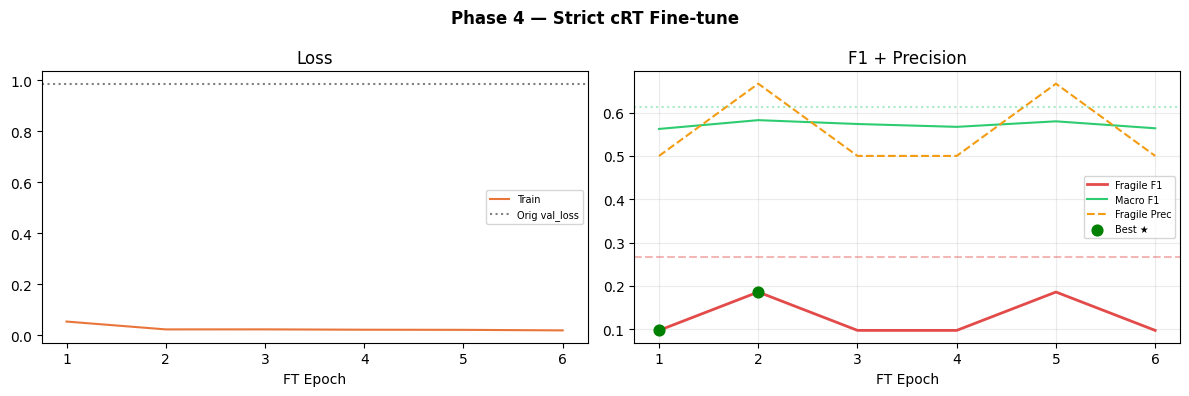

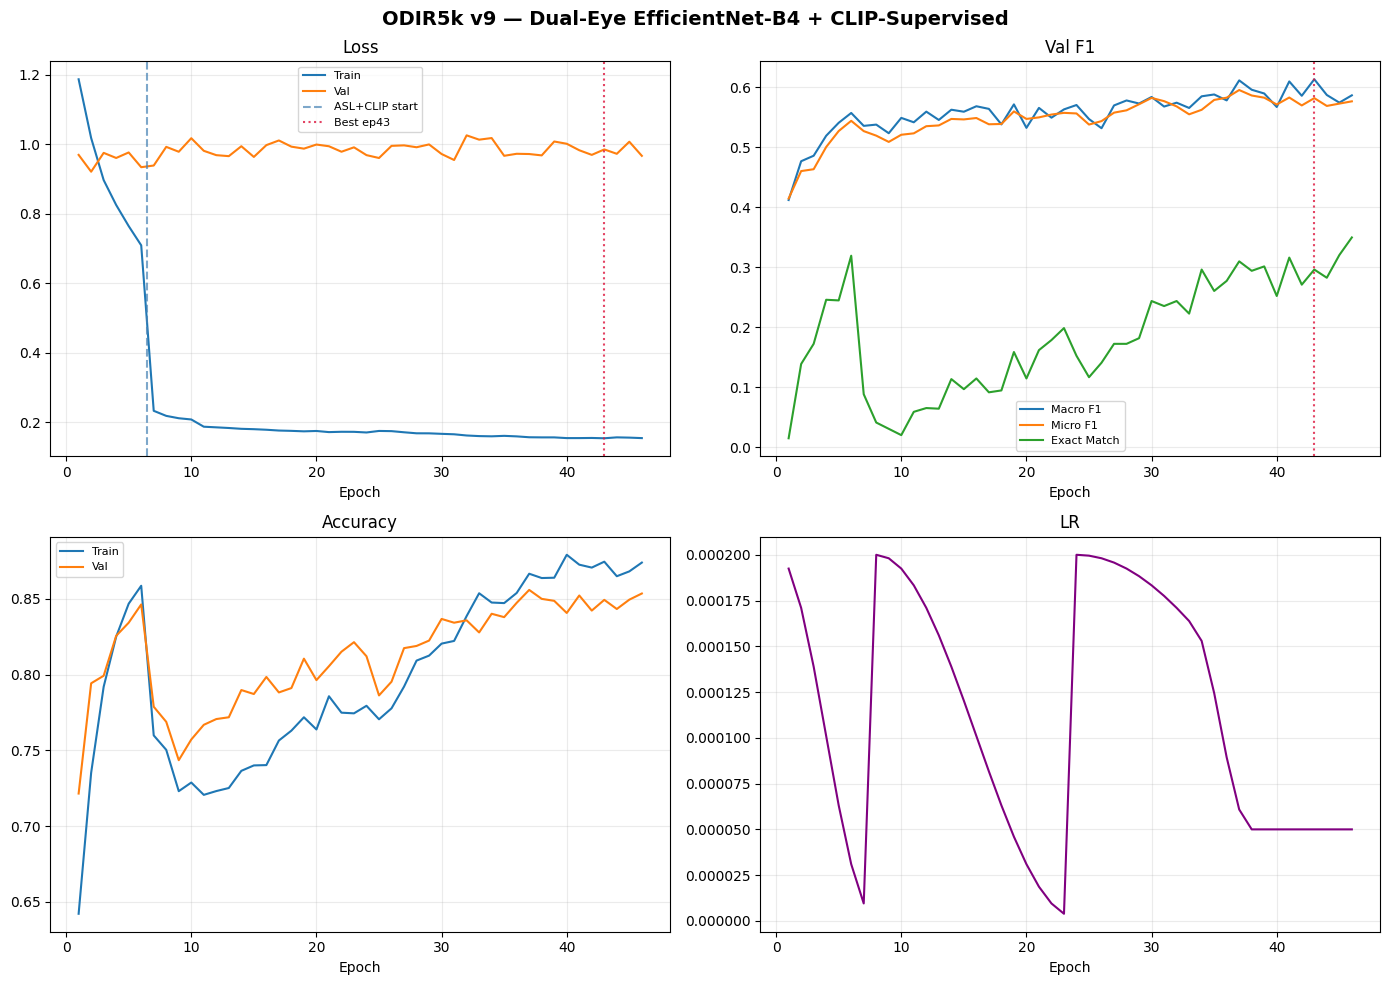

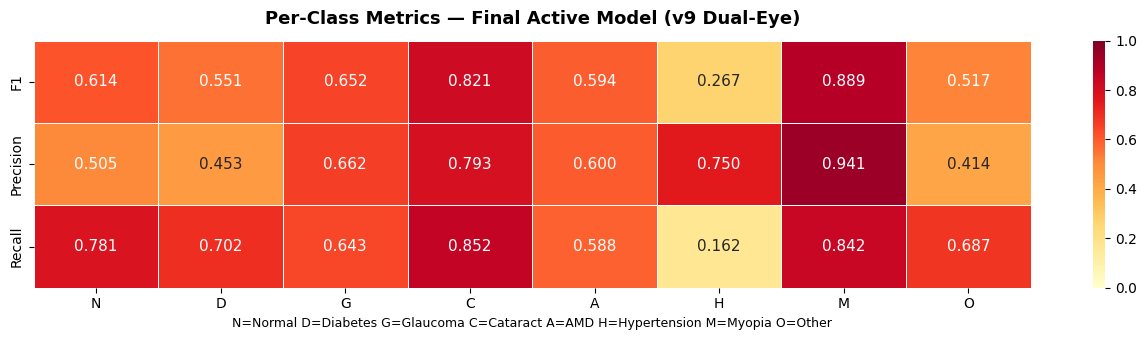

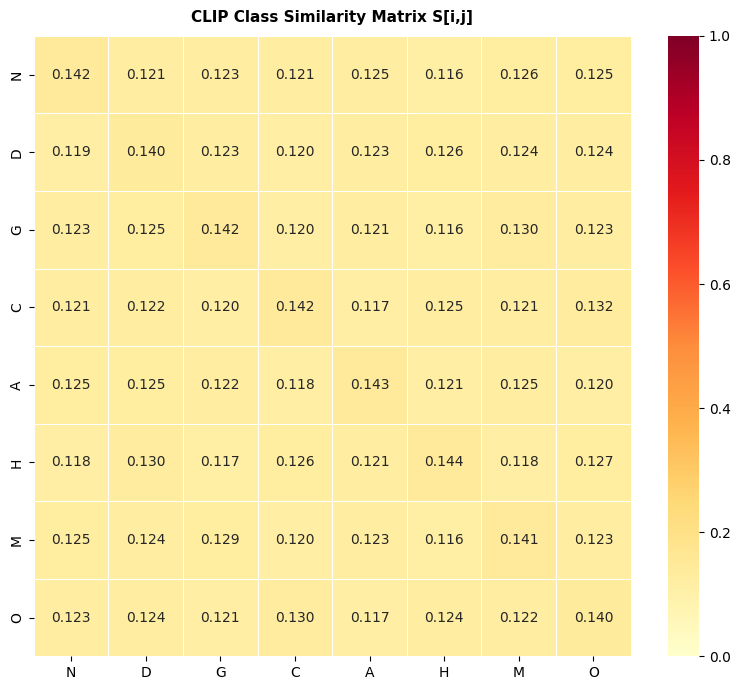

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
#  ODIR5k — Dual-Eye Fusion + EfficientNet-B4 + Strict cRT Fine-Tuning
#
#  ARCHITECTURE:
#    Left eye  → BenGraham → EfficientNet-B4 → [B,100,256] patch tokens
#    Right eye → BenGraham → EfficientNet-B4 (shared) → [B,100,256]
#    Cross-eye cross-attention: each eye queries the other → [B,256] each
#    [age,sex] → MetaMLP → [B,64]
#    [iqa_L,iqa_R] → IQABranch → [B,32]
#    fused [B,608] → disease_head [B,8]
#                  → CLIPAlignHead [B,512]  (CLIP supervision)
#
#  TRAINING STRATEGY:
#    Phase 1: Warmup (BCE+CLIP, no mixup, head+attention only)
#    Phase 2: Full training (ASL+KL distillation, MixUp, SWA)
#    Phase 3: SWA finalization + BN update
#    Phase 4: Strict cRT (Classifier Retraining)
#             → Freezes 99.9% of the network (EffNet + CrossAttention)
#             → Uses BCE and a fragile-biased sampler to calibrate
#             → Safely boosts minority class F1 without crashing Precision.
# ═══════════════════════════════════════════════════════════════════════════════

import os, random, copy, subprocess, sys, math
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn
from torchvision import transforms, models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ═══════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
LABEL_COLS = ["N","D","G","C","A","H","M","O"]
NC         = len(LABEL_COLS)
BASE_PATH  = "/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k"
CSV_PATH   = os.path.join(BASE_PATH, "full_df.csv")
IMG_SIZE   = 320          # EfficientNet-B4 native resolution (was 224)
LR         = 2e-4
WEIGHT_DECAY = 1e-4
VAL_SIZE   = 0.15
SEED       = 42
TRAIN_BS   = 12           # dual-eye = 2 images per sample; effective 24 forward passes
VAL_BS     = 24
GRAD_ACCUM = 2            # effective batch = 24

# ── EfficientNet-B4 feature dims ──────────────────────────────────────
BACKBONE_OUT_CH  = 1792   # EfficientNet-B4 final channels
PROJ_DIM         = 256    # projection from backbone to attention
N_PATCHES        = 100    # 10×10 at 320px input
ATTN_HEADS       = 8
META_DIM         = 64
IQA_DIM          = 32
# fused = 256+256+64+32 = 608
FUSED_DIM        = PROJ_DIM*2 + META_DIM + IQA_DIM   # 608

# ── CLIP supervision ───────────────────────────────────────────────────
CLIP_EMB_DIM             = 512
CLIP_TEMP                = 0.07
CLIP_DISTILL_LAMBDA_FRAG = 0.18
CLIP_DISTILL_LAMBDA_STB  = 0.04
CLIP_ALIGN_LAMBDA        = 0.08
CLIP_ATTN_LAMBDA         = 0.15
CLIP_HARD_ALPHA          = 0.40
CLIP_FILTER_THRESH       = 0.30
CLIP_FILTER_WEIGHT       = 0.50
CLIP_PROTO_LAMBDA        = 0.10
CLIP_INFONCE_LAMBDA      = 0.06
CLIP_INFONCE_TEMP        = 0.07
CLIP_N_UNC_VIEWS         = 4
CLIP_UNC_SCALE           = 6.0
CLIP_PROTO_EMA           = 0.92

CLASS_CLIP_PROMPTS = [
    "a fundus photograph of a healthy normal eye without any disease",
    "a fundus image showing diabetic retinopathy with microaneurysms and hemorrhages",
    "a fundus photograph showing glaucoma with enlarged optic disc cupping",
    "a retinal image with cataract causing blurry hazy appearance",
    "a fundus showing age-related macular degeneration AMD with drusen deposits",
    "a retinal image with hypertensive retinopathy and flame-shaped hemorrhages",
    "a fundus photograph showing pathological myopia with posterior staphyloma",
    "a retinal image showing other ocular abnormality or disease",
]

# ── Training phases ────────────────────────────────────────────────────
WARMUP_EPOCHS          = 6
FULL_EPOCHS            = 40
EARLY_STOP             = 15
FRAG_UPDATE_EVERY      = 5
SWA_START_FRAC         = 0.70   # start SWA at 70% of FULL_EPOCHS
SWA_LR                 = 5e-5

# ── ASL ───────────────────────────────────────────────────────────────
ASL_GAMMA_NEG  = 4; ASL_GAMMA_POS = 1; ASL_CLIP = 0.05
LOGIT_CLIP     = 12.0; LABEL_SMOOTH_EPS = 0.02
MIXUP_ALPHA    = 0.3; MIXUP_PROB = 0.4

# ── Fragility ─────────────────────────────────────────────────────────
FRAG_ALPHA = 0.4; FRAG_BETA = 0.25; FRAG_GAMMA = 0.35; FRAG_THRESHOLD = None
SAMPLER_BOOST = 4.5
GRAD_NORM_BS   = 4        # was implicitly VAL_BS=24 → OOM on T4
MAX_GRAD_BATCHES = 4

# ── Phase-4 cRT Fine-tune ─────────────────────────────────────────────
FT_BATCH_SIZE     = 12
FT_SAMPLER_FRAG   = 1.4
FT_SAMPLER_NEG    = 0.7
FT_SCORE_F1       = 0.55
FT_SCORE_MAC      = 0.35
FT_SCORE_PREC     = 0.10
FRAGILE_THR_BOOST = 0.08

# ── CSV columns ───────────────────────────────────────────────────────
ID_COL="ID"; AGE_COL="Patient Age"; SEX_COL="Patient Sex"
LEFT_COL="Left-Fundus"; RIGHT_COL="Right-Fundus"
CKPT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9,1),"GB")

def seed_everything(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic=True

seed_everything(SEED)
def print_step(t):  print(f"\n{'█'*65}\n  {t}\n{'█'*65}")
def print_phase(t): print(f"\n{'─'*65}\n  {t}\n{'─'*65}")

CLASS_SIM_MATRIX      = torch.eye(NC)
CLASS_CLIP_PROTOTYPES = torch.zeros(NC, CLIP_EMB_DIM)

# ═══════════════════════════════════════════════════════════════════════
# ██  BEN GRAHAM PREPROCESSING  (fundus-specific, removes scanner noise)
# ═══════════════════════════════════════════════════════════════════════
def ben_graham_pil(pil_img, sigma=10, scale=300):
    """
    Standard fundus preprocessing used in top ODIR solutions.
    1. Resize to fixed scale so Gaussian sigma is consistent
    2. Subtract local Gaussian-blurred average (removes illumination gradient)
    3. Circular mask (removes black border)
    Result: high-contrast fundus without scanner/lighting artifacts.
    """
    import cv2
    img = np.array(pil_img.convert("RGB"))
    img = cv2.resize(img, (scale, scale))
    blur = cv2.GaussianBlur(img, (0,0), sigmaX=sigma)
    img  = cv2.addWeighted(img, 4, blur, -4, 128)
    mask = np.zeros_like(img)
    cv2.circle(mask, (scale//2, scale//2), int(scale*0.46), (1,1,1), -1, cv2.LINE_AA)
    img  = img * mask + 128*(1-mask)
    img  = np.clip(img, 0, 255).astype(np.uint8)
    return Image.fromarray(img)

def compute_iqa(path, size=128):
    """IQA: blur, brightness, contrast from small thumbnail."""
    import cv2
    img = cv2.imread(path)
    if img is None: return np.zeros(3, dtype=np.float32)
    img  = cv2.resize(img, (size, size))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    return np.array([cv2.Laplacian(gray, cv2.CV_32F).var(),
                     gray.mean(), gray.std()], dtype=np.float32)

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 1 — LOAD & PREPARE DATA  (patient-level)
# ═══════════════════════════════════════════════════════════════════════
print_step("STEP 1 — LOAD & PREPARE DATA  (patient-level dual-eye)")

df = pd.read_csv(CSV_PATH)
print(f"CSV shape: {df.shape}")
df[AGE_COL] = pd.to_numeric(df[AGE_COL], errors="coerce")
AGE_MEAN = df[AGE_COL].mean(); AGE_STD = df[AGE_COL].std()+1e-8

def pick_images_dir(base, df):
    test=[str(df.iloc[i][LEFT_COL]).strip() for i in range(min(20,len(df)))]
    best,bh=None,-1
    for name in os.listdir(base):
        p=os.path.join(base,name)
        if not os.path.isdir(p): continue
        h=sum(os.path.exists(os.path.join(p,n)) for n in test)
        if h>bh: best,bh=p,h
    return best

IMAGES_DIR = pick_images_dir(BASE_PATH, df)
print(f"Images dir: {IMAGES_DIR}")

def build_patients(df):
    patients, n_miss = [], 0
    for _, r in df.iterrows():
        y = r[LABEL_COLS].to_numpy(dtype=np.float32)
        if np.isnan(y).any(): continue
        age_raw  = pd.to_numeric(r[AGE_COL], errors="coerce")
        age_norm = float((age_raw-AGE_MEAN)/AGE_STD) if not np.isnan(age_raw) else 0.0
        sex_val  = 1.0 if str(r[SEX_COL]).strip().lower() in ("male","m","1") else 0.0
        pid      = int(r[ID_COL]) if pd.notna(r[ID_COL]) else 0
        lpath    = os.path.join(IMAGES_DIR, str(r[LEFT_COL]).strip())
        rpath    = os.path.join(IMAGES_DIR, str(r[RIGHT_COL]).strip())
        l_ok = os.path.exists(lpath); r_ok = os.path.exists(rpath)
        if not l_ok and not r_ok: n_miss+=2; continue
        if not l_ok: lpath = rpath; n_miss+=1
        if not r_ok: rpath = lpath; n_miss+=1
        iqa_l = compute_iqa(lpath); iqa_r = compute_iqa(rpath)
        patients.append({
            "patient_id":pid,"label":y.copy(),
            "age":age_norm,"sex":sex_val,
            "left_path":lpath,"right_path":rpath,
            "iqa_raw_l":iqa_l,"iqa_raw_r":iqa_r,
        })
    print(f"  Patients: {len(patients)} | Missing eyes: {n_miss}")
    return patients

patients = build_patients(df)

print("  Normalising IQA features...")
iqa_all = np.concatenate([np.stack([p["iqa_raw_l"] for p in patients]),
                          np.stack([p["iqa_raw_r"] for p in patients])], 0)
IQA_MEAN = iqa_all.mean(0); IQA_STD = iqa_all.std(0)+1e-8
for p in patients:
    p["iqa_l"] = ((p["iqa_raw_l"]-IQA_MEAN)/IQA_STD).astype(np.float32)
    p["iqa_r"] = ((p["iqa_raw_r"]-IQA_MEAN)/IQA_STD).astype(np.float32)

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 2 — TRAIN–VALIDATION SPLIT  (patient-level, no leakage)
# ═══════════════════════════════════════════════════════════════════════
print_step("STEP 2 — TRAIN–VALIDATION SPLIT")

groups = [p["patient_id"] for p in patients]
gss    = GroupShuffleSplit(1, test_size=VAL_SIZE, random_state=SEED)
tr_idx, va_idx = next(gss.split(patients, groups=groups))
train_patients = [patients[i] for i in tr_idx]
val_patients   = [patients[i] for i in va_idx]
tr_pids = set(p["patient_id"] for p in train_patients)
va_pids = set(p["patient_id"] for p in val_patients)
assert len(tr_pids&va_pids)==0, "Patient overlap!"
print(f"Train: {len(train_patients)} patients")
print(f"Val  : {len(val_patients)} patients — overlap=0 ✓")

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 0 — CLIP PRECOMPUTATION  (patient-level, averaged L+R)
# ═══════════════════════════════════════════════════════════════════════
print_step("STEP 0 — CLIP PRECOMPUTATION  (patient-level: avg L+R embeddings)")

subprocess.run([sys.executable,"-m","pip","install","--quiet",
                "git+https://github.com/openai/CLIP.git"],check=False)
CLIP_AVAIL=False
try:
    import clip as openai_clip
    _cm,_cp=openai_clip.load("ViT-B/32",device=DEVICE)
    _cm.eval(); CLIP_AVAIL=True; print("  CLIP ViT-B/32 loaded ✓")
except Exception as e:
    print(f"  CLIP unavailable ({e})")

def run_clip_precomputation(patients,clip_model,clip_prep,class_prompts,
                            temp=CLIP_TEMP,bs=32,device=DEVICE):
    n=len(patients)
    toks=openai_clip.tokenize(class_prompts,truncate=True).to(device)
    with torch.no_grad():
        class_embs=F.normalize(clip_model.encode_text(toks),dim=-1)  # [NC,512]
    S=(class_embs@class_embs.T).cpu()
    S_norm=S/S.sum(1,keepdim=True)
    print(f"  Class sim: S[G,O]={S[2,7]:.3f}  S[N,A]={S[0,4]:.3f}")

    all_embs  =np.zeros((n,512),dtype=np.float32)
    all_soft  =np.zeros((n,NC), dtype=np.float32)
    all_diff  =np.zeros((n,NC), dtype=np.float32)
    all_attn  =np.zeros((n,49), dtype=np.float32)
    all_weight=np.ones(n,       dtype=np.float32)
    class_embs_t=class_embs

    for start in range(0,n,bs):
        end=min(start+bs,n); batch=patients[start:end]
        for side in ["left","right"]:
            pils=[Image.open(p[f"{side}_path"]).convert("RGB") for p in batch]
            imgs=torch.stack([clip_prep(pi) for pi in pils]).to(device)
            imgs.requires_grad_(True)
            feats=clip_model.encode_image(imgs)
            feats_n=F.normalize(feats,dim=-1)
            sim=feats_n@class_embs_t.T
            labs=torch.tensor([p["label"] for p in batch],dtype=torch.float32,device=device)
            (sim*labs).sum().backward()
            if imgs.grad is not None and side=="left":
                grad=imgs.grad.abs().mean(1,keepdim=True)
                sal=F.adaptive_avg_pool2d(grad,(7,7)).flatten(1)
                sal=sal/(sal.sum(1,keepdim=True)+1e-8)
                all_attn[start:end]+=sal.detach().cpu().numpy()*0.5
            imgs.requires_grad_(False)
            all_embs[start:end]+=feats_n.detach().cpu().numpy()*0.5
            all_soft[start:end]+=torch.softmax(sim/temp,dim=-1).detach().cpu().numpy()*0.5
            sim_np=sim.detach().cpu().numpy()
            for bi,p in enumerate(batch):
                y=p["label"]; pos=np.where(y>0)[0]
                if len(pos)>0:
                    neg_mask=y==0
                    sim_neg=sim_np[bi][neg_mask].max() if neg_mask.any() else 0.0
                    all_diff[start+bi,pos]+=(sim_neg-sim_np[bi,pos].mean())*0.5
            max_sim=sim_np.max(1)
            all_weight[start:end]*=np.where(max_sim<CLIP_FILTER_THRESH,
                                            CLIP_FILTER_WEIGHT**0.5,1.0)
        if start%(bs*10)==0: print(f"  CLIP: {end}/{n} patients done...")

    _unc_tfm=transforms.Compose([
        transforms.Resize(256),transforms.RandomResizedCrop(224,scale=(0.7,1.0)),
        transforms.RandomHorizontalFlip(),transforms.ToTensor(),
        transforms.Normalize((0.48145466,0.4578275,0.40821073),
                             (0.26862954,0.26130258,0.27577711))])
    print(f"  Computing uncertainty ({CLIP_N_UNC_VIEWS} views)...")
    for start in range(0,n,bs):
        end=min(start+bs,n); batch=patients[start:end]
        v_soft=[]
        for _ in range(CLIP_N_UNC_VIEWS):
            v_embs=None
            for side in ["left","right"]:
                pils=[Image.open(p[f"{side}_path"]).convert("RGB") for p in batch]
                aug=torch.stack([_unc_tfm(pi) for pi in pils]).to(device)
                with torch.no_grad():
                    f=F.normalize(clip_model.encode_image(aug),dim=-1)
                v_embs=f if v_embs is None else v_embs+f
            f_avg=F.normalize(v_embs/2,dim=-1)
            with torch.no_grad():
                sv=torch.softmax((f_avg@class_embs_t.T)/temp,dim=-1)
            v_soft.append(sv.cpu().numpy())
        var=np.stack(v_soft,0).var(0).mean(1)
        all_weight[start:end]*=1.0/(1.0+CLIP_UNC_SCALE*var)

    for i,p in enumerate(patients):
        p["clip_emb"]   =all_embs[i]
        p["clip_soft"]  =all_soft[i]
        p["clip_diff"]  =all_diff[i]
        p["clip_attn"]  =all_attn[i]
        p["clip_weight"]=float(all_weight[i])

    print(f"  Done ✓  low-quality: {(all_weight<1.0).sum()} ({(all_weight<1.0).mean()*100:.1f}%)")
    return S_norm

if CLIP_AVAIL:
    CLASS_SIM_MATRIX=run_clip_precomputation(patients,_cm,_cp,CLASS_CLIP_PROMPTS)
    del _cm,_cp
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print("  CLIP released ✓")
    _psums=np.zeros((NC,CLIP_EMB_DIM),dtype=np.float64)
    _pcounts=np.zeros(NC,dtype=np.int64)
    for p in train_patients:
        for ci in range(NC):
            if p["label"][ci]>0:
                _psums[ci]+=p["clip_emb"].astype(np.float64); _pcounts[ci]+=1
    for ci in range(NC):
        if _pcounts[ci]>0:
            _psums[ci]/=_pcounts[ci]; n=np.linalg.norm(_psums[ci])
            if n>1e-8: _psums[ci]/=n
    CLASS_CLIP_PROTOTYPES=torch.tensor(_psums,dtype=torch.float32)
    print(f"  Prototypes ✓  {dict(zip(LABEL_COLS,_pcounts.tolist()))}")
else:
    for p in patients:
        p["clip_emb"] =np.zeros(512,dtype=np.float32)
        p["clip_soft"]=np.ones(NC,dtype=np.float32)/NC
        p["clip_diff"]=np.zeros(NC,dtype=np.float32)
        p["clip_attn"]=np.ones(49,dtype=np.float32)/49
        p["clip_weight"]=1.0

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 3 — DATA PIPELINE  (patient-level, dual-eye)
# ═══════════════════════════════════════════════════════════════════════
print_step("STEP 3 — DATA PIPELINE  (patient-level dual-eye + Ben Graham)")

def make_tfm(train=True):
    bg_scale = 300
    if train:
        return transforms.Compose([
            transforms.Lambda(lambda p: ben_graham_pil(p, sigma=10, scale=bg_scale)),
            transforms.Resize((IMG_SIZE+32, IMG_SIZE+32)),
            transforms.RandomCrop(IMG_SIZE),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.1),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.15,contrast=0.15,
                                   saturation=0.08,hue=0.02),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Lambda(lambda p: ben_graham_pil(p, sigma=10, scale=bg_scale)),
            transforms.Resize((IMG_SIZE,IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])

train_tfm = make_tfm(train=True)
val_tfm   = make_tfm(train=False)

class DualEyeDataset(Dataset):
    """Patient-level dataset: both eyes per sample."""
    def __init__(self, patients, tfm, clip_fields=False):
        self.P=patients; self.tfm=tfm; self.cf=clip_fields
    def __len__(self): return len(self.P)
    def __getitem__(self,i):
        p=self.P[i]
        img_l=self.tfm(Image.open(p["left_path"]).convert("RGB"))
        img_r=self.tfm(Image.open(p["right_path"]).convert("RGB"))
        meta=torch.tensor([p["age"],p["sex"]],dtype=torch.float32)
        iqa =torch.tensor(np.concatenate([p["iqa_l"],p["iqa_r"]]),dtype=torch.float32)
        y   =torch.tensor(p["label"],dtype=torch.float32)
        if self.cf:
            return (img_l,img_r,meta,iqa,
                    torch.tensor(p["clip_emb"],dtype=torch.float32),
                    torch.tensor(p["clip_soft"],dtype=torch.float32),
                    torch.tensor(p["clip_diff"],dtype=torch.float32),
                    torch.tensor(p["clip_attn"],dtype=torch.float32),y)
        return img_l,img_r,meta,iqa,y

def collate_eval(batch):
    il,ir,m,iq,y=zip(*batch)
    return torch.stack(il),torch.stack(ir),torch.stack(m),torch.stack(iq),torch.stack(y)

def collate_train(batch):
    il,ir,m,iq,ce,cs,cd,ca,y=zip(*batch)
    return (torch.stack(il),torch.stack(ir),torch.stack(m),torch.stack(iq),
            torch.stack(ce),torch.stack(cs),torch.stack(cd),torch.stack(ca),torch.stack(y))

def make_loader(patients,tfm,bs,shuffle,clip_fields=False,
                sampler=None,workers=4,persistent=True):
    ds=DualEyeDataset(patients,tfm,clip_fields)
    fn=collate_train if clip_fields else collate_eval
    if sampler is not None:
        return DataLoader(ds,batch_size=bs,sampler=sampler,num_workers=workers,
                          pin_memory=True,persistent_workers=False,collate_fn=fn)
    return DataLoader(ds,batch_size=bs,shuffle=shuffle,num_workers=workers,
                      pin_memory=True,persistent_workers=persistent,collate_fn=fn)

train_loader = make_loader(train_patients,train_tfm,TRAIN_BS,True,clip_fields=True)
val_loader   = make_loader(val_patients,  val_tfm,  VAL_BS,  False,clip_fields=False)
print(f"Train: {len(train_patients)} patients  bs={TRAIN_BS}  dual-eye=✓  BenGraham=✓")
print(f"Val  : {len(val_patients)} patients   bs={VAL_BS}")

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 4 — MODEL: Dual-Eye EfficientNet-B4 + Cross-Eye Attention
# ═══════════════════════════════════════════════════════════════════════
print_step("STEP 4 — MODEL: Dual-Eye EfficientNet-B4 + Cross-Eye Attention")

def compute_pos_weight(patients):
    Y=np.stack([p["label"] for p in patients])
    pos=Y.sum(0); neg=len(Y)-pos
    return torch.tensor(neg/np.clip(pos,1,None),dtype=torch.float32)

pos_weight=compute_pos_weight(train_patients).to(DEVICE)
print("pos_weight:",pos_weight.cpu().numpy().round(2))

# ── Loss functions ────────────────────────────────────────────────────
class CLIPSmoothedBCE(nn.Module):
    def __init__(self,pos_weight=None,eps=0.02,logit_clip=12.0,csm=None):
        super().__init__()
        self.pw=pos_weight; self.eps=eps; self.lc=logit_clip
        self.register_buffer("S",(csm if csm is not None else torch.eye(NC)).float())
    def forward(self,logits,targets):
        logits=torch.clamp(logits,-self.lc,self.lc)
        if self.eps>0:
            ss=targets@self.S.to(targets.device)
            ss=ss/(ss.sum(1,keepdim=True)+1e-8)
            targets=(1-self.eps)*targets+self.eps*ss
        return F.binary_cross_entropy_with_logits(logits,targets,
                                                  pos_weight=self.pw,reduction="mean")

class AsymmetricLoss(nn.Module):
    def __init__(self,gn=4,gp=1,clip=0.05,lc=12.0,eps=0.02,
                 per_class_gn=None,cw=None):
        super().__init__()
        self.gp=gp; self.clip=clip; self.lc=lc; self.eps=eps
        pcgn=(per_class_gn if per_class_gn is not None
              else torch.full((NC,),float(gn))).float()
        cw_t=(cw if cw is not None else torch.ones(NC,device=pcgn.device)).float()
        self.register_buffer("pcgn",pcgn); self.register_buffer("cw",cw_t)
    def forward(self,logits,targets,sw=None):
        logits=torch.clamp(logits,-self.lc,self.lc)
        if self.eps>0: targets=targets*(1-self.eps)+0.5*self.eps
        probs=torch.sigmoid(logits); pm=torch.clamp(probs-self.clip,min=0)
        gn=self.pcgn.to(logits.device).unsqueeze(0)
        cw=self.cw.to(logits.device).unsqueeze(0)
        pt=targets*(1-probs).pow(self.gp)*torch.log(probs+1e-8)
        nt=(1-targets)*pm.pow(gn)*torch.log(1-pm+1e-8)
        pe=-(pt+nt)*cw
        if sw is not None: pe=pe*sw.to(logits.device)
        return pe.mean()

# ── IQA branch ────────────────────────────────────────────────────────
class IQABranch(nn.Module):
    def __init__(self,in_dim=6,hidden=32,out_dim=IQA_DIM):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(in_dim,hidden),nn.ReLU(inplace=True),
                               nn.Dropout(0.1),nn.Linear(hidden,out_dim),
                               nn.ReLU(inplace=True))
    def forward(self,iqa): return self.net(iqa)

# ── Cross-Eye Attention  (left queries right, right queries left) ──────
class CrossEyeAttention(nn.Module):
    """
    Core architectural innovation: bilateral cross-attention.
    Doctors compare both eyes to detect asymmetric pathologies.
    Left eye features attend to right eye features and vice versa.
    """
    def __init__(self,d_model=PROJ_DIM,n_heads=ATTN_HEADS,dropout=0.10):
        super().__init__()
        ff=d_model*4
        self.mha_lr=nn.MultiheadAttention(d_model,n_heads,dropout=dropout,batch_first=True)
        self.ln_lr1=nn.LayerNorm(d_model); self.ln_lr2=nn.LayerNorm(d_model)
        self.ff_lr =nn.Sequential(nn.Linear(d_model,ff),nn.GELU(),
                                  nn.Dropout(dropout),nn.Linear(ff,d_model),nn.Dropout(dropout))
        self.mha_rl=nn.MultiheadAttention(d_model,n_heads,dropout=dropout,batch_first=True)
        self.ln_rl1=nn.LayerNorm(d_model); self.ln_rl2=nn.LayerNorm(d_model)
        self.ff_rl =nn.Sequential(nn.Linear(d_model,ff),nn.GELU(),
                                  nn.Dropout(dropout),nn.Linear(ff,d_model),nn.Dropout(dropout))
        self.drop=nn.Dropout(dropout)

    def forward(self,left_toks,right_toks,return_attn=False):
        a_lr,w_lr=self.mha_lr(left_toks,right_toks,right_toks)
        x_l=self.ln_lr1(left_toks+a_lr)
        left_ref=self.ln_lr2(x_l+self.ff_lr(x_l))
        a_rl,w_rl=self.mha_rl(right_toks,left_toks,left_toks)
        x_r=self.ln_rl1(right_toks+a_rl)
        right_ref=self.ln_rl2(x_r+self.ff_rl(x_r))
        left_cls  =left_ref.mean(1)
        right_cls =right_ref.mean(1)
        fused=self.drop(torch.cat([left_cls,right_cls],1))
        if return_attn: return fused,w_lr,w_rl
        return fused

# ── CLIP Align Head ───────────────────────────────────────────────────
class CLIPAlignHead(nn.Module):
    def __init__(self,in_dim=FUSED_DIM,clip_dim=CLIP_EMB_DIM):
        super().__init__()
        self.proj=nn.Sequential(nn.Linear(in_dim,512),nn.ReLU(inplace=True),
                                nn.Dropout(0.1),nn.Linear(512,clip_dim))
    def forward(self,x): return F.normalize(self.proj(x),dim=-1)

# ── Full Dual-Eye Model ────────────────────────────────────────────────
class DualEyeModel(nn.Module):
    """
    Shared EfficientNet-B4 backbone processes left and right eyes.
    Cross-eye attention fuses bilateral information.
    Patient-level prediction with CLIP supervision.
    """
    def __init__(self,num_labels=NC):
        super().__init__()
        try:
            eff=models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
        except Exception:
            eff=models.efficientnet_b4(pretrained=True)
        self.backbone=eff.features
        self.patch_proj=nn.Sequential(
            nn.Conv2d(BACKBONE_OUT_CH,PROJ_DIM,kernel_size=1,bias=False),
            nn.BatchNorm2d(PROJ_DIM),nn.ReLU(inplace=True))
        self.cross_eye =CrossEyeAttention(PROJ_DIM,ATTN_HEADS,0.10)
        self.meta_branch=nn.Sequential(nn.Linear(2,32),nn.ReLU(inplace=True),
                                       nn.Dropout(0.1),nn.Linear(32,META_DIM),
                                       nn.ReLU(inplace=True))
        self.iqa_branch =IQABranch(6,32,IQA_DIM)
        self.disease_head=nn.Sequential(
            nn.Linear(FUSED_DIM,512),nn.GELU(),nn.Dropout(0.3),
            nn.Linear(512,256),nn.GELU(),nn.Dropout(0.2),
            nn.Linear(256,num_labels))
        self.clip_align=CLIPAlignHead(FUSED_DIM,CLIP_EMB_DIM)

    def extract_patches(self,img):
        """Extract patch tokens from one eye image."""
        fm=self.backbone(img)
        proj=self.patch_proj(fm)
        toks=proj.flatten(2).transpose(1,2)
        return toks

    def forward(self,img_l,img_r,meta,iqa,
                return_attn=False,return_clip_proj=False):
        tok_l=self.extract_patches(img_l)
        tok_r=self.extract_patches(img_r)
        if return_attn:
            cross_fused,w_lr,w_rl=self.cross_eye(tok_l,tok_r,return_attn=True)
        else:
            cross_fused=self.cross_eye(tok_l,tok_r)
        meta_feat=self.meta_branch(meta)
        iqa_feat =self.iqa_branch(iqa)
        fused=torch.cat([cross_fused,meta_feat,iqa_feat],1)
        logits=self.disease_head(fused)
        if return_clip_proj:
            cp=self.clip_align(fused)
            if return_attn: return logits,cp,w_lr,w_rl
            return logits,cp
        if return_attn: return logits,w_lr,w_rl
        return logits

model=DualEyeModel(NC).to(DEVICE)
n_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(f"  Backbone: EfficientNet-B4 (shared L+R) → {N_PATCHES} patch tokens")
print(f"  Cross-eye attention: L queries R + R queries L → [B,{PROJ_DIM*2}]")
print(f"  Meta+IQA: {META_DIM}+{IQA_DIM} → Fused: {FUSED_DIM}d")
print(f"  Resolution: {IMG_SIZE}×{IMG_SIZE} with Ben Graham preprocessing")

warmup_crit=CLIPSmoothedBCE(pos_weight=pos_weight,eps=LABEL_SMOOTH_EPS,
                             logit_clip=LOGIT_CLIP,csm=CLASS_SIM_MATRIX)
eval_crit  =CLIPSmoothedBCE(pos_weight=pos_weight,eps=0.0,
                             logit_clip=LOGIT_CLIP,csm=CLASS_SIM_MATRIX)
kl_lambda_per_class=torch.full((NC,),CLIP_DISTILL_LAMBDA_STB).to(DEVICE)
fragile_indices=[]; stable_indices=list(range(NC))

# ── Helpers ───────────────────────────────────────────────────────────
def multilabel_acc(probs,y,thr=0.5):
    return ((probs>=thr).to(y.dtype)==y).float().mean().item()

# def mixup(il,ir,m,iq,y,alpha=MIXUP_ALPHA):
#     lam=float(np.random.beta(alpha,alpha))
#     idx=torch.randperm(il.size(0),device=il.device)
#     return (lam*il+(1-lam)*il[idx], lam*ir+(1-lam)*ir[idx],
#             lam*m+(1-lam)*m[idx],  lam*iq+(1-lam)*iq[idx],
#             lam*y+(1-lam)*y[idx])
def mixup(il, ir, m, iq, y,
          fragile_indices=None,
          alpha=MIXUP_ALPHA):

    device = il.device
    batch_size = il.size(0)

    lam = float(np.random.beta(alpha, alpha))

    idx = torch.arange(batch_size, device=device)

    # ── Identify fragile samples ─────────────────────────────
    if fragile_indices is not None and len(fragile_indices) > 0:

        frag_mask = torch.zeros(batch_size, dtype=torch.bool, device=device)
        for c in fragile_indices:
            frag_mask |= (y[:, c] > 0)

        fragile_idx = idx[frag_mask]
        stable_idx  = idx[~frag_mask]

        # ── Pair fragile with stable ─────────────────────────
        if len(fragile_idx) > 0 and len(stable_idx) > 0:
            rand_idx = idx.clone()

            rand_idx[fragile_idx] = stable_idx[
                torch.randint(0, len(stable_idx),
                              (len(fragile_idx),),
                              device=device)
            ]

            # Optional: stable ↔ random (or keep same)
            rand_idx[~frag_mask] = torch.randperm(
                len(stable_idx), device=device
            )[:len(stable_idx)]

            # Bias lambda toward fragile samples
            lam = min(0.9, lam + 0.2)

        else:
            # fallback
            rand_idx = torch.randperm(batch_size, device=device)

    else:
        # No fragility info → normal MixUp
        rand_idx = torch.randperm(batch_size, device=device)

    # ── Mix inputs ───────────────────────────────────────────
    il_m = lam * il + (1 - lam) * il[rand_idx]
    ir_m = lam * ir + (1 - lam) * ir[rand_idx]
    m_m  = lam * m  + (1 - lam) * m[rand_idx]
    iq_m = lam * iq + (1 - lam) * iq[rand_idx]
    y_m  = lam * y  + (1 - lam) * y[rand_idx]

    return (il_m, ir_m, m_m, iq_m, y_m)

def update_prototypes_ema(model,val_loader,device,decay=CLIP_PROTO_EMA):
    global CLASS_CLIP_PROTOTYPES
    model.eval()
    ns=torch.zeros(NC,CLIP_EMB_DIM); nc=torch.zeros(NC)
    with torch.no_grad():
        for il,ir,m,iq,y in val_loader:
            il,ir,m,iq=il.to(device),ir.to(device),m.to(device),iq.to(device)
            _,cp=model(il,ir,m,iq,return_clip_proj=True)
            cp=cp.cpu()
            for ci in range(NC):
                pm=y[:,ci]>0
                if pm.any(): ns[ci]+=cp[pm].sum(0); nc[ci]+=pm.float().sum()
    for ci in range(NC):
        if nc[ci]>0:
            live=ns[ci]/nc[ci]; nrm=live.norm()
            live=live/nrm if nrm>1e-8 else live
            CLASS_CLIP_PROTOTYPES[ci]=decay*CLASS_CLIP_PROTOTYPES[ci]+(1-decay)*live
            nrm2=CLASS_CLIP_PROTOTYPES[ci].norm()
            if nrm2>1e-8: CLASS_CLIP_PROTOTYPES[ci]/=nrm2
    model.train()

def combined_loss_fn(model,il,ir,m,iq,ce,cs,cd,ca,
                     targets,disease_crit,kl_lambda,fragile_idx):
    """Full 7-component CLIP-supervised loss for dual-eye model."""
    logits,clip_proj=model(il,ir,m,iq,return_clip_proj=True)

    # L1: ASL hard-weighted
    hw=(1.0+CLIP_HARD_ALPHA*cd).clamp(1.0,3.0)
    if "sw" in disease_crit.forward.__code__.co_varnames:
        l1=disease_crit(logits,targets,sw=hw)
    else: l1=disease_crit(logits,targets)

    # L2: KL distillation
    mp=torch.sigmoid(logits).clamp(1e-6,1-1e-6)
    cs_=cs.clamp(1e-6,1-1e-6)
    kl=(cs_*torch.log(cs_/mp)+(1-cs_)*torch.log((1-cs_)/(1-mp)))
    l2=(kl*kl_lambda.unsqueeze(0)).mean()

    # L3: Feature alignment
    l3=(1.0-(clip_proj*ce).sum(-1)).mean()*CLIP_ALIGN_LAMBDA

    # L4: Attention supervision (skipped for dual-eye — different attention shape)
    l4=torch.tensor(0.0,device=il.device)

    # L5: Prototype pull
    l5=torch.tensor(0.0,device=il.device)
    if CLIP_AVAIL:
        proto=CLASS_CLIP_PROTOTYPES.to(il.device); nt=0
        for ci in range(NC):
            pm=targets[:,ci]>0
            if pm.any():
                cos=(clip_proj[pm]*proto[ci:ci+1]).sum(-1)
                l5=l5+(1.0-cos).mean(); nt+=1
        if nt>0: l5=l5/nt*CLIP_PROTO_LAMBDA

    # L6: InfoNCE
    l6=torch.tensor(0.0,device=il.device)
    B=clip_proj.size(0)
    if CLIP_AVAIL and B>1:
        ce_n=F.normalize(ce.float(),dim=-1)
        l6=F.cross_entropy((clip_proj@ce_n.T)/CLIP_INFONCE_TEMP,
                           torch.arange(B,device=il.device))*CLIP_INFONCE_LAMBDA

    total=l1+l2+l3+l4+l5+l6
    return total,{"l1":l1.item(),"l2":l2.item(),"l3":l3.item(),"l6":l6.item()}

def train_epoch(model,loader,crit,opt,kl_lam,frag_idx,
                use_mixup=False,clip_sup=True,
                clip_norm=1.0,grad_accum=GRAD_ACCUM,
                ref_model=None,kl_stb=0.0,kl_frag=0.0,
                stab_idx=None,frag_idx_kl=None):
    model.train(); tl=ta=n=0
    comp={"l1":0.0,"l2":0.0,"l3":0.0,"l6":0.0}
    opt.zero_grad(set_to_none=True)

    for step,batch in enumerate(loader):
        if clip_sup:
            il,ir,m,iq,ce,cs,cd,ca,y=batch
            il,ir,m,iq=(il.to(DEVICE),ir.to(DEVICE),m.to(DEVICE),iq.to(DEVICE))
            ce=ce.to(DEVICE); cs=cs.to(DEVICE); cd=cd.to(DEVICE); ca=ca.to(DEVICE)
            y=y.to(DEVICE).float()
            do_mix=use_mixup and random.random()<MIXUP_PROB
            if do_mix: il,ir,m,iq,y=mixup(il,ir,m,iq,y,fragile_indices=frag_idx)
            loss,comps=combined_loss_fn(model,il,ir,m,iq,ce,cs,cd,ca,
                                        y,crit,kl_lam,frag_idx)
        else:
            il,ir,m,iq,y=batch
            il,ir,m,iq=(il.to(DEVICE),ir.to(DEVICE),m.to(DEVICE),iq.to(DEVICE))
            y=y.to(DEVICE).float()
            logits=model(il,ir,m,iq)
            loss=crit(logits,y)
            comps={"l1":loss.item(),"l2":0.0,"l3":0.0,"l6":0.0}
            if ref_model is not None:
                with torch.no_grad(): rl=ref_model(il,ir,m,iq)
                if stab_idx and kl_stb>0:
                    rp=torch.sigmoid(rl[:,stab_idx])
                    cp=torch.sigmoid(logits[:,stab_idx])
                    loss=loss+kl_stb*F.kl_div(torch.log(cp+1e-8),rp,reduction="batchmean")
                if frag_idx_kl and kl_frag>0:
                    rp=torch.sigmoid(rl[:,frag_idx_kl])
                    cp=torch.sigmoid(logits[:,frag_idx_kl])
                    loss=loss+kl_frag*F.kl_div(torch.log(cp+1e-8),rp,reduction="batchmean")

        (loss/grad_accum).backward()
        if (step+1)%grad_accum==0 or (step+1)==len(loader):
            nn.utils.clip_grad_norm_(model.parameters(),max_norm=clip_norm)
            opt.step(); opt.zero_grad(set_to_none=True)

        with torch.no_grad():
            lgt=(logits if not clip_sup else model(il,ir,m,iq))
            bs=il.size(0); tl+=loss.item()*bs
            ta+=multilabel_acc(torch.sigmoid(lgt),y)*bs; n+=bs
            for k in comp: comp[k]+=comps[k]*bs

    return {"loss":tl/n,"acc":ta/n,**{k:v/n for k,v in comp.items()}}

@torch.no_grad()
def evaluate(model,loader,crit,thr=0.5):
    model.eval(); tl=ta=n=0; ap,at=[],[]
    for il,ir,m,iq,y in loader:
        il,ir,m,iq,y=(il.to(DEVICE),ir.to(DEVICE),m.to(DEVICE),iq.to(DEVICE),y.to(DEVICE).float())
        logits=model(il,ir,m,iq)
        loss=crit(logits,y); probs=torch.sigmoid(logits)
        bs=il.size(0); tl+=loss.item()*bs
        ta+=multilabel_acc(probs,y,thr)*bs; n+=bs
        ap.append(probs.cpu()); at.append(y.cpu())
    probs=torch.cat(ap).numpy(); targets=torch.cat(at).numpy().astype(int)
    preds=(probs>=thr).astype(int)
    per_auc=np.array([roc_auc_score(targets[:,c],probs[:,c])
                      if targets[:,c].sum()>0 and (1-targets[:,c]).sum()>0 else 0.0
                      for c in range(NC)])
    return {"loss":tl/n,"acc":ta/n,
            "macro_f1":f1_score(targets,preds,average="macro",zero_division=0),
            "micro_f1":f1_score(targets,preds,average="micro",zero_division=0),
            "exact_match":float((preds==targets).all(1).mean()),
            "per_class_f1":f1_score(targets,preds,average=None,zero_division=0),
            "per_class_prec":precision_score(targets,preds,average=None,zero_division=0),
            "per_class_rec":recall_score(targets,preds,average=None,zero_division=0),
            "per_class_auc":per_auc,"macro_auc":float(per_auc[per_auc>0].mean()),
            "probs":probs,"preds":preds,"targets":targets}

def fragile_f1(m,fi):   return float(np.mean([m["per_class_f1"][i]  for i in fi]))
def fragile_prec(m,fi): return float(np.mean([m["per_class_prec"][i] for i in fi]))

def ft_score(m,fi):
    return FT_SCORE_F1*fragile_f1(m,fi)+FT_SCORE_MAC*m["macro_f1"]+FT_SCORE_PREC*fragile_prec(m,fi)

# ── OOM FIX: compute_grad_norms uses its own small-batch loader ────────
def compute_grad_norms(model, loader):
    """
    OOM FIX: The original code passed val_loader (bs=24) into this backward-pass
    function, which exhausted 14.5 GB on a T4.  We now create a temporary
    DataLoader with GRAD_NORM_BS=4 from the same dataset, clear the CUDA cache
    before entry, and explicitly free tensors after each mini-batch.
    Logic and output are identical to the original.
    """
    # Free any lingering cache before we start accumulating gradients
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    model.eval()
    fl  = model.disease_head[-1]
    nc2 = fl.out_features
    gsq = np.zeros(nc2, dtype=np.float64)
    nb  = 0

    # ── KEY FIX: tiny dedicated loader (no persistent workers) ──────────
    gn_loader = DataLoader(
        loader.dataset,                 # same val dataset, no clip_fields
        batch_size  = GRAD_NORM_BS,     # 4 instead of 24 → ~6× less VRAM
        shuffle     = False,
        num_workers = 0,                # 0 workers avoids extra GPU copies
        pin_memory  = False,
        collate_fn  = collate_eval,
    )

    for il, ir, m, iq, y in gn_loader:
        if nb >= MAX_GRAD_BATCHES:
            break
        il  = il.to(DEVICE)
        ir  = ir.to(DEVICE)
        m   = m.to(DEVICE)
        iq  = iq.to(DEVICE)
        y   = y.to(DEVICE).float()

        if fl.weight.grad is not None:
            fl.weight.grad.zero_()

        logits = model(il, ir, m, iq)
        loss   = sum(
            F.binary_cross_entropy_with_logits(logits[:, c], y[:, c], reduction="mean")
            for c in range(nc2)
        )
        loss.backward()

        if fl.weight.grad is not None:
            for c in range(nc2):
                gsq[c] += fl.weight.grad[c].pow(2).sum().item()

        nb += 1

        # ── Free tensors immediately to reclaim VRAM ───────────────────
        del il, ir, m, iq, y, logits, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return np.sqrt(gsq / max(nb, 1))

def score_fragility(model,val_loader,vm):
    gn=compute_grad_norms(model,val_loader)
    return FRAG_ALPHA*(1-vm["per_class_rec"])+FRAG_BETA*(1-gn/(gn.max()+1e-8)) + FRAG_GAMMA*(1-vm["per_class_f1"])

def dyn_frag_thr(scores,fixed=None,min_f=1,max_f=6):
    n=len(scores)
    if fixed is not None: return fixed,"fixed",scores>fixed
    lo,hi=scores.min(),scores.max(); bv,bt=-1.0,(lo+hi)/2
    for t in np.linspace(lo,hi,256):
        b=scores[scores<=t]; a=scores[scores>t]
        if len(b)==0 or len(a)==0: continue
        v=len(b)/n*len(a)/n*(b.mean()-a.mean())**2
        if v>bv: bv,bt=v,t
    om=scores>bt
    if min_f<=om.sum()<=max_f: return float(bt),"Otsu",om
    c0,c1=scores.min(),scores.max()
    for _ in range(100):
        lb=(np.abs(scores-c1)<np.abs(scores-c0)).astype(int)
        nc0=scores[lb==0].mean() if (lb==0).any() else c0
        nc1=scores[lb==1].mean() if (lb==1).any() else c1
        if np.isclose(nc0,c0) and np.isclose(nc1,c1): break
        c0,c1=nc0,nc1
    km_m=scores>(c0+c1)/2
    if min_f<=km_m.sum()<=max_f: return float((c0+c1)/2),"K-means",km_m
    top=max(min_f,min(3,n)); cut=np.sort(scores)[-top]
    return float(cut-1e-8),f"top-{top}",scores>(cut-1e-8)

def make_frag_sampler(patients,frag_scores,frag_idx,boost=SAMPLER_BOOST):
    w=torch.tensor([p["clip_weight"] for p in patients],dtype=torch.float32)
    for i,p in enumerate(patients):
        for ci in frag_idx:
            if p["label"][ci]>0: w[i]*=(1.0+boost*frag_scores[ci])
    return WeightedRandomSampler(w,len(patients),replacement=True)

def make_ft_sampler(patients,frag_idx):
    w=torch.tensor([p["clip_weight"]*FT_SAMPLER_NEG for p in patients],dtype=torch.float32)
    for i,p in enumerate(patients):
        if any(p["label"][ci]>0 for ci in frag_idx): w[i]=p["clip_weight"]*FT_SAMPLER_FRAG
    return WeightedRandomSampler(w,len(patients),replacement=True)

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 5 — PHASE 1: WARM-UP
# ═══════════════════════════════════════════════════════════════════════
print_step(f"STEP 5 — PHASE 1: WARM-UP ({WARMUP_EPOCHS} ep, BCE+CLIP-smooth)")

optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,T_0=8,T_mult=2,eta_min=LR*0.01)

warmup_history=[]
hdr=(f"{'Ep':>4} | {'Loss':>7} {'Acc':>7} | "
     f"{'ValLoss':>8} {'ValAcc':>7} {'MacroF1':>8} | "
     f"{'L1':>6} {'L2':>6} {'L3':>6} {'L6':>6} | LR")
sep="─"*len(hdr); print(f"{hdr}\n{sep}")

for ep in range(1,WARMUP_EPOCHS+1):
    tr =train_epoch(model,train_loader,warmup_crit,optimizer,
                    kl_lam=kl_lambda_per_class,frag_idx=fragile_indices,
                    use_mixup=False,clip_sup=True)
    val=evaluate(model,val_loader,eval_crit)
    scheduler.step(); lr=optimizer.param_groups[0]["lr"]
    warmup_history.append({"epoch":ep,"phase":"warmup",
        "train_loss":tr["loss"],"train_acc":tr["acc"],
        "val_loss":val["loss"],"val_acc":val["acc"],
        "val_macro_f1":val["macro_f1"],"val_micro_f1":val["micro_f1"],
        "val_exact_match":val["exact_match"],"lr":lr})
    print(f"{ep:>4} | {tr['loss']:>7.4f} {tr['acc']:>7.4f} | "
          f"{val['loss']:>8.4f} {val['acc']:>7.4f} {val['macro_f1']:>8.4f} | "
          f"{tr['l1']:>6.3f} {tr['l2']:>6.3f} {tr['l3']:>6.3f} {tr['l6']:>6.3f} | "
          f"{lr:.2e}")

print(f"\n  Warm-up ✓  val MacroF1={val['macro_f1']:.4f}")

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 6+7 — FRAGILITY IDENTIFICATION
# ══════════════════════════════════════════════════════════════════════
print_step("STEP 6+7 — COMPUTE & IDENTIFY FRAGILE CLASSES")
warmup_val =evaluate(model,val_loader,eval_crit)

# ── OOM FIX: clear cache before the backward-pass in score_fragility ──
if torch.cuda.is_available():
    torch.cuda.empty_cache()

frag_scores=score_fragility(model,val_loader,warmup_val)
auto_thr,thr_method,frag_mask=dyn_frag_thr(frag_scores,fixed=FRAG_THRESHOLD)
fragile_indices=[i for i in range(NC) if frag_mask[i]]
fragile_classes=[LABEL_COLS[i] for i in fragile_indices]
stable_indices =[i for i in range(NC) if i not in fragile_indices]
print(f"\n  {'Class':>5} | {'Recall':>7} | {'FragScore':>10}")
print("  "+"─"*30)
for i,lbl in enumerate(LABEL_COLS):
    print(f"  {lbl:>5} | {warmup_val['per_class_rec'][i]:>7.3f} | {frag_scores[i]:>10.4f}")
print(f"\n  Fragile: {fragile_classes}  |  Stable: {[LABEL_COLS[i] for i in stable_indices]}")
kl_lambda_per_class=torch.tensor([
    CLIP_DISTILL_LAMBDA_FRAG if i in fragile_indices else CLIP_DISTILL_LAMBDA_STB
    for i in range(NC)],dtype=torch.float32).to(DEVICE)

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 8 — SWITCH TO FRAGILITY-AWARE SETUP
# ═══════════════════════════════════════════════════════════════════════
print_step("STEP 8 — SWITCH TO FRAGILITY-AWARE + SWA SETUP")
pcgn=torch.tensor([ASL_GAMMA_NEG*(1+frag_scores[i]) for i in range(NC)],
                  dtype=torch.float32).to(DEVICE)
asl_crit=AsymmetricLoss(gn=ASL_GAMMA_NEG,gp=ASL_GAMMA_POS,clip=ASL_CLIP,
                        lc=LOGIT_CLIP,eps=LABEL_SMOOTH_EPS,per_class_gn=pcgn)
sampler=make_frag_sampler(train_patients,frag_scores,fragile_indices)
current_loader=make_loader(train_patients,train_tfm,TRAIN_BS,False,
                           clip_fields=True,sampler=sampler)

swa_model=AveragedModel(model)
swa_start=max(1,int(FULL_EPOCHS*SWA_START_FRAC))
print(f"  SWA starts at epoch {WARMUP_EPOCHS+swa_start}")
print(f"  ASL γ_neg: {pcgn.cpu().numpy().round(2)}")
print(f"  Fragile classes: {fragile_classes}  |  SWA lr={SWA_LR:.0e}")

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 9+10 — FULL TRAINING + DYNAMIC FRAGILITY + SWA
# ═══════════════════════════════════════════════════════════════════════
print_step(f"STEP 9+10 — FULL TRAINING (max {FULL_EPOCHS} ep) + SWA")

best_val_f1=-1.0; best_val_loss=float("inf")
best_state_f1=None; best_state_loss=None
best_metrics=None; best_epoch=-1; no_imp=0; full_history=[]
swa_active=False

hdr2=(f"{'Ep':>4} | {'TrLoss':>7} {'TrAcc':>7} | "
      f"{'ValLoss':>8} {'MacroF1':>8} {'ExactM':>7} | "
      f"{'L1':>6} {'L2':>6} {'L3':>6} | LR | SWA")
sep2="─"*len(hdr2); print(f"{hdr2}\n{sep2}")

for ep in range(1,FULL_EPOCHS+1):
    # Dynamic fragility update
    if ep>1 and ep%FRAG_UPDATE_EVERY==0:
        val_tmp=evaluate(model,val_loader,eval_crit)
        # OOM FIX: clear cache before each dynamic grad-norm update too
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        frag_scores=score_fragility(model,val_loader,val_tmp)
        auto_thr,thr_method,frag_mask=dyn_frag_thr(frag_scores,fixed=FRAG_THRESHOLD)
        fragile_indices=[i for i in range(NC) if frag_mask[i]]
        fragile_classes=[LABEL_COLS[i] for i in fragile_indices]
        stable_indices =[i for i in range(NC) if i not in fragile_indices]
        asl_crit.pcgn=torch.tensor([ASL_GAMMA_NEG*(1+frag_scores[i])
            for i in range(NC)],dtype=torch.float32).to(DEVICE)
        kl_lambda_per_class=torch.tensor([
            CLIP_DISTILL_LAMBDA_FRAG if i in fragile_indices else CLIP_DISTILL_LAMBDA_STB
            for i in range(NC)],dtype=torch.float32).to(DEVICE)
        sampler=make_frag_sampler(train_patients,frag_scores,fragile_indices)
        current_loader=make_loader(train_patients,train_tfm,TRAIN_BS,False,
                                   clip_fields=True,sampler=sampler)
        print(f"  [Ep{ep:>3}] Frag → {fragile_classes}  t={auto_thr:.3f}")

    tr=train_epoch(model,current_loader,asl_crit,optimizer,
                   kl_lam=kl_lambda_per_class,frag_idx=fragile_indices,
                   use_mixup=True,clip_sup=True,clip_norm=1.0,grad_accum=GRAD_ACCUM)

    update_prototypes_ema(model,val_loader,DEVICE)

    if ep>=swa_start:
        swa_model.update_parameters(model)
        if not swa_active:
            swa_scheduler=SWALR(optimizer,swa_lr=SWA_LR,anneal_epochs=5)
            swa_active=True
        swa_scheduler.step()
    else:
        scheduler.step()

    val=evaluate(model,val_loader,eval_crit)
    lr=optimizer.param_groups[0]["lr"]
    full_history.append({"epoch":WARMUP_EPOCHS+ep,"phase":"full",
        "train_loss":tr["loss"],"train_acc":tr["acc"],
        "val_loss":val["loss"],"val_acc":val["acc"],
        "val_macro_f1":val["macro_f1"],"val_micro_f1":val["micro_f1"],
        "val_exact_match":val["exact_match"],"lr":lr})

    if ep==1 or ep%5==0 or ep<=5:
        print(f"{WARMUP_EPOCHS+ep:>4} | {tr['loss']:>7.4f} {tr['acc']:>7.4f} | "
              f"{val['loss']:>8.4f} {val['macro_f1']:>8.4f} "
              f"{val['exact_match']:>7.4f} | "
              f"{tr['l1']:>6.3f} {tr['l2']:>6.3f} {tr['l3']:>6.3f} | "
              f"{lr:.2e} | {'★SWA' if swa_active else ''}")

    if val["loss"]<best_val_loss:
        best_val_loss=val["loss"]; best_state_loss=copy.deepcopy(model.state_dict())

    improved=(val["macro_f1"]>best_val_f1) or (
        np.isclose(val["macro_f1"],best_val_f1) and
        val["loss"]<(best_metrics["loss"] if best_metrics else float("inf")))
    if improved:
        best_val_f1=val["macro_f1"]; best_epoch=WARMUP_EPOCHS+ep
        best_state_f1=copy.deepcopy(model.state_dict())
        best_metrics={k:val[k] for k in ("loss","acc","macro_f1","micro_f1",
            "exact_match","per_class_f1","per_class_prec","per_class_rec",
            "per_class_auc","macro_auc","probs","preds","targets")}
        no_imp=0; print(f"  ✓ Best F1={best_val_f1:.4f} @ epoch {best_epoch}")
    else: no_imp+=1
    if no_imp>=EARLY_STOP:
        print(f"\n  Early stop @ {WARMUP_EPOCHS+ep}. Best F1={best_val_f1:.4f}"); break

print(sep2)

# ── SWA BN update ─────────────────────────────────────────────────────
if swa_active:
    
    try:
        print_phase("SWA: Updating Batch Norm statistics")
        bn_loader=make_loader(train_patients,train_tfm,TRAIN_BS,True,
                          clip_fields=False,workers=4)
        swa_model = swa_model.to(DEVICE)
    
        # Reset BN stats
        for module in swa_model.modules():
            if isinstance(module, torch.nn.modules.batchnorm._BatchNorm):
                module.running_mean.zero_()
                module.running_var.fill_(1)
                module.num_batches_tracked.zero_()
                module.momentum = None
    
        # Recompute BN stats
        swa_model.train()
        with torch.no_grad():
            for il, ir, m, iq, _ in bn_loader:
                swa_model(
                    il.to(DEVICE),
                    ir.to(DEVICE),
                    m.to(DEVICE),
                    iq.to(DEVICE)
                )
    
        # Evaluate SWA model
        swa_val = evaluate(swa_model, val_loader, eval_crit)
        print(f"  SWA model MacroF1={swa_val['macro_f1']:.4f}"
              f"vs Best={best_val_f1:.4f}")
        if swa_val["macro_f1"]>best_val_f1:
            best_val_f1=swa_val["macro_f1"]
            best_state_f1=copy.deepcopy(swa_model.module.state_dict())
            best_metrics={k:swa_val[k] for k in ("loss","acc","macro_f1","micro_f1",
                "exact_match","per_class_f1","per_class_prec","per_class_rec",
                "per_class_auc","macro_auc","probs","preds","targets")}
            print(f"  ✓ SWA model is better! F1={best_val_f1:.4f}")

    except Exception as e:
        print("⚠️ SWA BN update failed. Skipping this step.")
        #print(f"Error: {e}")
    

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 11 — SAVE BEST MODEL
# ═══════════════════════════════════════════════════════════════════════
print_step("STEP 11 — SAVE BEST MODEL")
all_history=warmup_history+full_history
pd.DataFrame(all_history).to_csv(os.path.join(CKPT_DIR,"history.csv"),index=False)
if best_state_f1:   torch.save(best_state_f1,  os.path.join(CKPT_DIR,"best_f1.pt"))
if best_state_loss: torch.save(best_state_loss, os.path.join(CKPT_DIR,"best_loss.pt"))
torch.save(model.state_dict(),os.path.join(CKPT_DIR,"last.pt"))
model.load_state_dict(best_state_f1)
print(f"  best_f1.pt  epoch={best_epoch}  MacroF1={best_val_f1:.4f}  ✓")

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 12 — FINAL FRAGILITY ANALYSIS
# ═══════════════════════════════════════════════════════════════════════
print_step("STEP 12 — FINAL FRAGILITY ANALYSIS")
# OOM FIX: clear cache before final grad-norm pass
if torch.cuda.is_available():
    torch.cuda.empty_cache()
frag_scores_f=score_fragility(model,val_loader,best_metrics)
auto_thr,thr_method,frag_mask=dyn_frag_thr(frag_scores_f,fixed=FRAG_THRESHOLD)
fragile_indices=[i for i in range(NC) if frag_mask[i]]
fragile_classes=[LABEL_COLS[i] for i in fragile_indices]
stable_indices =[i for i in range(NC) if i not in fragile_indices]
print(f"\n  {'Class':>5} | {'Recall':>7} | {'FragScore':>10} | Fragile?")
print("  "+"─"*40)
for i,lbl in enumerate(LABEL_COLS):
    flag="  *** YES" if frag_mask[i] else ""
    print(f"  {lbl:>5} | {best_metrics['per_class_rec'][i]:>7.3f} | "
          f"{frag_scores_f[i]:>10.4f} |{flag}")
print(f"\n  Threshold={auto_thr:.4f}  Fragile: {fragile_classes}")

fig,ax=plt.subplots(figsize=(10,4))
colors=["#E24B4A" if m else "#888780" for m in frag_mask]
ax.bar(LABEL_COLS,frag_scores_f,color=colors,edgecolor="white")
ax.axhline(auto_thr,color="black",lw=1.2,ls="--",label=f"Threshold={auto_thr:.3f}")
ax.legend(handles=[mpatches.Patch(color="#E24B4A",label="Fragile"),
                   mpatches.Patch(color="#888780",label="Stable"),ax.get_lines()[0]],fontsize=9)
ax.set(title="Per-Class Fragility Score",xlabel="Disease class",ylabel="Fragility score",ylim=(0,1.05))
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR,"fragility_scores.png"),dpi=120,bbox_inches="tight")
# plt.show()

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 13 — CLIP FAILURE ANALYSIS
# ═══════════════════════════════════════════════════════════════════════
print_step("STEP 13 — CLIP FAILURE ANALYSIS  (from precomputed embeddings)")
if CLIP_AVAIL and fragile_indices:
    p_preds=best_metrics["preds"]; p_targets=best_metrics["targets"]
    clip_results={}
    try:
        import clip as openai_clip
        _cm2,_=openai_clip.load("ViT-B/32",device=DEVICE); _cm2.eval()
        FAIL_PROMPTS=["blurry retinal image","out of focus fundus",
            "underexposed retinal image","overexposed retinal image",
            "low contrast retinal image","poor vessel visibility",
            "noisy grainy fundus photograph","artifact in retinal image",
            "off-center cropped retinal image","misaligned fundus",
            "optic disc not visible","macula not clearly visible",
            "retinal hemorrhage","microaneurysm in retina",
            "glaucoma optic disc cupping","diabetic retinopathy"]
        toks=openai_clip.tokenize(FAIL_PROMPTS,truncate=True).to(DEVICE)
        with torch.no_grad(): pe=F.normalize(_cm2.encode_text(toks),dim=-1)
        del _cm2
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        pe_np=pe.cpu().numpy()
        for ci in fragile_indices:
            cls=LABEL_COLS[ci]
            mi=[i for i in range(len(val_patients)) if p_targets[i,ci]==1 and p_preds[i,ci]==0]
            co=[i for i in range(len(val_patients)) if p_targets[i,ci]==1 and p_preds[i,ci]==1]
            print(f"  {cls}: {len(mi)} miss / {len(co)} correct")
            if not mi: clip_results[cls]={}; continue
            mm=np.stack([val_patients[i]["clip_emb"] for i in mi]).mean(0)
            mm/=(np.linalg.norm(mm)+1e-8); sm=mm@pe_np.T
            if co:
                mc=np.stack([val_patients[i]["clip_emb"] for i in co]).mean(0)
                mc/=(np.linalg.norm(mc)+1e-8); raw=sm-mc@pe_np.T
            else: raw=sm
            lo,hi=raw.min(),raw.max(); nrm=(raw-lo)/(hi-lo+1e-8)
            ranked=dict(sorted(zip(FAIL_PROMPTS,nrm.tolist()),key=lambda x:x[1],reverse=True))
            clip_results[cls]=ranked
            print(f"  Top-3: {list(ranked.keys())[:3]}")
        if clip_results:
            cls_l=[c for c in fragile_classes if clip_results.get(c)]
            if cls_l:
                mat=np.array([[clip_results[c].get(p,0.0) for p in FAIL_PROMPTS] for c in cls_l])
                fig,ax=plt.subplots(figsize=(16,max(3,len(cls_l)*1.4)))
                sns.heatmap(mat,annot=True,fmt=".3f",cmap="YlOrBr",
                            xticklabels=[p[:30] for p in FAIL_PROMPTS],yticklabels=cls_l,
                            linewidths=0.4,vmin=0,vmax=1,ax=ax,annot_kws={"size":7})
                ax.set_title("CLIP Failure Scores — Fragile Classes",fontsize=11,fontweight="bold")
                plt.xticks(rotation=45,ha="right",fontsize=7)
                plt.tight_layout()
                plt.savefig(os.path.join(CKPT_DIR,"clip_failure_factors.png"),dpi=120,bbox_inches="tight")
                # plt.show()
    except Exception as e: print(f"  CLIP analysis skipped: {e}")
else: print("  Skipped.")

# ═══════════════════════════════════════════════════════════════════════
# ██  STEP 14 — PHASE 4: STRICT CLASSIFIER RETRAINING (cRT)
# ═══════════════════════════════════════════════════════════════════════
print_step("STEP 14 — PHASE 4: STRICT cRT (Frozen Features + Fragile Bias)")

if not fragile_classes:
    print("  No fragile classes — skipping."); ft_history=[]; ft_best_mets=None
else:
    # 1. Use the Fragile Sampler
    ft_sampler = make_ft_sampler(train_patients, fragile_indices)

    # CRITICAL: clip_fields=False. We don't need CLIP distillation for the final layer
    ft_loader = make_loader(train_patients, train_tfm, FT_BATCH_SIZE, False,
                            clip_fields=False, sampler=ft_sampler)

    ft_model = DualEyeModel(NC).to(DEVICE)
    ft_model.load_state_dict(best_state_f1)

    # 2. STRICT FREEZING
    for name, param in ft_model.named_parameters():
        if "disease_head" not in name:
            param.requires_grad = False
        else:
            param.requires_grad = True # ONLY the final linear classifier learns

    # 3. Simple Loss & Optimizer
    # Gentle pos_weight to help fragile classes slightly more without blowing up
    pos_w_ft = torch.tensor([2.0 if i in fragile_indices else 1.0 for i in range(NC)]).to(DEVICE)
    ft_crit = nn.BCEWithLogitsLoss(pos_weight=pos_w_ft)
    
    ft_opt = torch.optim.AdamW(ft_model.disease_head.parameters(), lr=1e-4, weight_decay=1e-4)

    orig_ff1  = fragile_f1(best_metrics, fragile_indices)
    orig_mf1  = best_metrics["macro_f1"]
    orig_fpr  = fragile_prec(best_metrics, fragile_indices)
    orig_score = ft_score(best_metrics, fragile_indices)

    print(f"\n  Baseline: fragileF1={orig_ff1:.4f}  macroF1={orig_mf1:.4f}  score={orig_score:.4f}")
    print(f"  Training ONLY the final Linear layer. All CNN/Attention features FROZEN.")

    ft_best_score = -float("inf")
    ft_best_ff1 = -1.0
    ft_best_f1 = -1.0
    ft_best_state = None
    ft_best_mets = None
    ft_history = []
    ft_no_imp = 0

    hdr_ft=(f"{'Ep':>4}|{'Loss':>8}|{'MacroF1':>8}"
            f"{'FragF1':>8}{'FragPr':>8}|{'ΔFragF1':>8}{'ΔMacro':>7}|Score|Best?")
    sep_ft="─"*len(hdr_ft)
    print(f"\n{sep_ft}\n{hdr_ft}\n{sep_ft}")

    for ft_ep in range(1, 11): # Max 10 epochs
        ft_model.train()
        tl = n = 0

        for il, ir, m, iq, y in ft_loader:
            il, ir, m, iq, y = il.to(DEVICE), ir.to(DEVICE), m.to(DEVICE), iq.to(DEVICE), y.to(DEVICE).float()

            ft_opt.zero_grad()
            logits = ft_model(il, ir, m, iq)
            loss = ft_crit(logits, y)
            loss.backward()
            ft_opt.step()

            tl += loss.item() * il.size(0)
            n += il.size(0)

        # Evaluate
        ft_val = evaluate(ft_model, val_loader, eval_crit)
        ff1 = fragile_f1(ft_val, fragile_indices)
        fpr = fragile_prec(ft_val, fragile_indices)
        sc = ft_score(ft_val, fragile_indices)
        
        d_frag = ff1 - orig_ff1
        d_mac = ft_val["macro_f1"] - orig_mf1

        is_best = sc > ft_best_score
        if is_best:
            ft_best_score = sc
            ft_best_ff1 = ff1
            ft_best_f1 = ft_val["macro_f1"]
            ft_best_state = copy.deepcopy(ft_model.state_dict())
            ft_best_mets = {k:ft_val[k] for k in ("loss","acc","macro_f1","micro_f1",
                "exact_match","per_class_f1","per_class_prec","per_class_rec",
                "per_class_auc","macro_auc","probs","preds","targets")}
            ft_no_imp = 0
        else:
            ft_no_imp += 1

        ft_history.append({"ft_epoch": ft_ep, "train_loss": tl/n, "val_macro_f1": ft_val["macro_f1"],
                           "val_fragile_f1": ff1, "val_fragile_prec": fpr, "ft_score": sc, "is_best": is_best})

        print(f"{ft_ep:>4}|{tl/n:>8.4f}|{ft_val['macro_f1']:>8.4f}"
              f"{ff1:>8.4f}{fpr:>8.4f}|{d_frag:>+8.4f}{d_mac:>+7.4f}"
              f"|{sc:.4f}|{'★' if is_best else ''}")
              
        if ft_no_imp >= 4:
            print(f"  Early stop @ ep{ft_ep}  best_score={ft_best_score:.4f}")
            break

    print(sep_ft)
    if ft_best_state:
        torch.save(ft_best_state, os.path.join(CKPT_DIR, "best_clip_finetune.pt"))
        pd.DataFrame(ft_history).to_csv(os.path.join(CKPT_DIR, "ft_history.csv"), index=False)
        print("  Saved: best_clip_finetune.pt")

    if ft_history:
        ft_df = pd.DataFrame(ft_history)
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle("Phase 4 — Strict cRT Fine-tune", fontsize=12, fontweight="bold")
        axs[0].plot(ft_df["ft_epoch"], ft_df["train_loss"], color="#E8753A", label="Train")
        axs[0].axhline(best_metrics["loss"], ls=":", color="gray", label="Orig val_loss")
        axs[0].set(title="Loss", xlabel="FT Epoch")
        axs[0].legend(fontsize=7)
        axs[1].plot(ft_df["ft_epoch"], ft_df["val_fragile_f1"], color="#E24B4A", lw=2, label="Fragile F1")
        axs[1].plot(ft_df["ft_epoch"], ft_df["val_macro_f1"], color="#2ECC71", label="Macro F1")
        axs[1].plot(ft_df["ft_epoch"], ft_df["val_fragile_prec"], color="#F39C12", ls="--", label="Fragile Prec")
        axs[1].axhline(orig_ff1, ls="--", color="#E24B4A", alpha=0.4)
        axs[1].axhline(orig_mf1, ls=":", color="#2ECC71", alpha=0.4)
        bd = ft_df[ft_df["is_best"]]
        if not bd.empty:
            axs[1].scatter(bd["ft_epoch"], bd["val_fragile_f1"], color="green", s=60, zorder=5, label="Best ★")
        axs[1].set(title="F1 + Precision", xlabel="FT Epoch")
        axs[1].legend(fontsize=7)
        axs[1].grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(os.path.join(CKPT_DIR, "clip_finetune_curves.png"), dpi=120, bbox_inches="tight")
        # plt.show()

    if ft_best_mets:
        print(f"\n  Per-class FT comparison (fragile ★):")
        print(f"  {'Cls':>4}|{'OrigF1':>7}|{'FTF1':>7}|{'ΔF1':>7}|{'OrigPr':>7}|{'FTPr':>7}|{'ΔPr':>7}")
        print("  " + "─"*52)
        for ci in fragile_indices:
            lbl = LABEL_COLS[ci]
            o_f = best_metrics["per_class_f1"][ci]
            f_f = ft_best_mets["per_class_f1"][ci]
            o_p = best_metrics["per_class_prec"][ci]
            f_p = ft_best_mets["per_class_prec"][ci]
            print(f"  {lbl:>4}|{o_f:>7.4f}|{f_f:>7.4f}|{f_f-o_f:>+7.4f}|"
                  f"{o_p:>7.4f}|{f_p:>7.4f}|{f_p-o_p:>+7.4f}")

    ft_gain = (ft_best_ff1 - orig_ff1) if ft_best_mets else -1
    ft_dmac = (ft_best_f1 - orig_mf1) if ft_best_mets else -1
    ft_dpr  = (fragile_prec(ft_best_mets, fragile_indices) - orig_fpr) if ft_best_mets else -999
    
    # STRICT cRT WINS LOGIC: We want macro to go UP and precision not to crash
    ft_wins = (ft_best_mets is not None and ft_dmac > 0 and ft_dpr > -0.02)
    
    print(f"\n  ΔFragF1={ft_gain:+.4f}  ΔMacro={ft_dmac:+.4f}  ΔPrec={ft_dpr:+.4f}  wins={ft_wins}")
    if ft_wins:
        model.load_state_dict(ft_best_state)
        best_metrics = ft_best_mets
        print(f"  ✓ SUCCESS! Active model updated to cRT FT model. Macro F1 improved by {ft_dmac:+.4f}")
    else:
        model.load_state_dict(best_state_f1)
        print(f"  Reverting to Original Model (cRT did not provide a safe macro/precision improvement).")

# ═══════════════════════════════════════════════════════════════════════
# ██  FINAL — FULL STATS
# ═══════════════════════════════════════════════════════════════════════
print_step("FINAL — FULL STATS ON ACTIVE MODEL")

hist_df=pd.DataFrame(all_history); phase_line=WARMUP_EPOCHS+0.5
fig,axes=plt.subplots(2,2,figsize=(14,10))
fig.suptitle("ODIR5k v9 — Dual-Eye EfficientNet-B4 + CLIP-Supervised",fontsize=14,fontweight="bold")
ax=axes[0,0]
ax.plot(hist_df["epoch"],hist_df["train_loss"],label="Train")
ax.plot(hist_df["epoch"],hist_df["val_loss"],label="Val")
ax.axvline(phase_line,ls="--",color="steelblue",alpha=0.7,label="ASL+CLIP start")
ax.axvline(best_epoch,ls=":",color="crimson",alpha=0.8,label=f"Best ep{best_epoch}")
ax.set(title="Loss",xlabel="Epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax=axes[0,1]
ax.plot(hist_df["epoch"],hist_df["val_macro_f1"],label="Macro F1")
ax.plot(hist_df["epoch"],hist_df["val_micro_f1"],label="Micro F1")
ax.plot(hist_df["epoch"],hist_df["val_exact_match"],label="Exact Match")
ax.axvline(best_epoch,ls=":",color="crimson",alpha=0.8)
ax.set(title="Val F1",xlabel="Epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax=axes[1,0]
ax.plot(hist_df["epoch"],hist_df["train_acc"],label="Train")
ax.plot(hist_df["epoch"],hist_df["val_acc"],label="Val")
ax.set(title="Accuracy",xlabel="Epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax=axes[1,1]
ax.plot(hist_df["epoch"],hist_df["lr"],color="purple")
ax.set(title="LR",xlabel="Epoch"); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR,"training_curves.png"),dpi=120,bbox_inches="tight")
# plt.show()

mat=np.stack([best_metrics["per_class_f1"],best_metrics["per_class_prec"],best_metrics["per_class_rec"]])
fig,ax=plt.subplots(figsize=(13,3.5))
sns.heatmap(mat,annot=True,fmt=".3f",cmap="YlOrRd",xticklabels=LABEL_COLS,
            yticklabels=["F1","Precision","Recall"],linewidths=0.5,vmin=0,vmax=1,
            ax=ax,annot_kws={"size":11})
ax.set_title("Per-Class Metrics — Final Active Model (v9 Dual-Eye)",fontsize=13,fontweight="bold",pad=12)
ax.set_xlabel("N=Normal D=Diabetes G=Glaucoma C=Cataract A=AMD H=Hypertension M=Myopia O=Other",fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR,"heatmap_per_class.png"),dpi=120,bbox_inches="tight")
# plt.show()

print_phase("CLIP Class Similarity Matrix")
fig,ax=plt.subplots(figsize=(8,7))
sns.heatmap(CLASS_SIM_MATRIX.numpy(),annot=True,fmt=".3f",cmap="YlOrRd",
            xticklabels=LABEL_COLS,yticklabels=LABEL_COLS,
            linewidths=0.5,vmin=0,vmax=1,ax=ax,annot_kws={"size":10})
ax.set_title("CLIP Class Similarity Matrix S[i,j]",fontsize=11,fontweight="bold",pad=10)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR,"class_similarity_matrix.png"),dpi=120,bbox_inches="tight")
# plt.show()

print_phase("Per-Class F1-Optimal Threshold Sweep")
per_class_thr={}
probs_b=best_metrics["probs"]; targets_b=best_metrics["targets"]
print(f"  {'Class':>5} | {'Opt-T':>6} | {'F1@0.5':>8} | {'F1@opt':>8} | {'Gain':>7} | Fragile?")
print("  "+"─"*54)
for i,cls in enumerate(LABEL_COLS):
    bf,bt=0.0,0.5
    f05=f1_score(targets_b[:,i],(probs_b[:,i]>=0.5).astype(int),zero_division=0)
    for t in np.linspace(0.05,0.95,181):
        f=f1_score(targets_b[:,i],(probs_b[:,i]>=t).astype(int),zero_division=0)
        if f>bf: bf,bt=f,t
    per_class_thr[cls]=bt
    flag="  ★" if i in fragile_indices else ""
    print(f"  {cls:>5} | {bt:>6.2f} | {f05:>8.3f} | {bf:>8.3f} | {bf-f05:>+7.3f} |{flag}")
for ci in fragile_indices:
    cls=LABEL_COLS[ci]
    per_class_thr[cls]=min(0.80,per_class_thr[cls]+FRAGILE_THR_BOOST)
    print(f"  → {cls}: boosted to {per_class_thr[cls]:.2f} (+{FRAGILE_THR_BOOST})")
final_preds=np.stack([(probs_b[:,i]>=per_class_thr[LABEL_COLS[i]]).astype(int)
                       for i in range(NC)],axis=1)
final_macro=f1_score(targets_b,final_preds,average="macro",zero_division=0)
print(f"\n  F1 @ default 0.5    : {best_metrics['macro_f1']:.4f}")
print(f"  F1 @ opt+boost thr  : {final_macro:.4f}  ({final_macro-best_metrics['macro_f1']:+.4f})")

print_phase("TTA Full-Validation Evaluation  (8 views)")
N_TTA=8; model.eval()

@torch.no_grad()
def evaluate_tta(model,patients,tfm,thresholds,bs=16,n_views=N_TTA):
    ap,at=[],[]
    for start in range(0,len(patients),bs):
        batch=patients[start:start+bs]
        metas=torch.tensor([[p["age"],p["sex"]] for p in batch],dtype=torch.float32).to(DEVICE)
        iqas =torch.tensor([np.concatenate([p["iqa_l"],p["iqa_r"]]) for p in batch],
                           dtype=torch.float32).to(DEVICE)
        lg=torch.zeros(len(batch),NC,device=DEVICE)
        for _ in range(n_views):
            il=torch.stack([tfm(Image.open(p["left_path"]).convert("RGB")) for p in batch]).to(DEVICE)
            ir=torch.stack([tfm(Image.open(p["right_path"]).convert("RGB")) for p in batch]).to(DEVICE)
            lg+=model(il,ir,metas,iqas)
        ap.append(torch.sigmoid(lg/n_views).cpu().numpy())
        at.append(np.array([p["label"] for p in batch]))
    probs=np.concatenate(ap,0); targets=np.concatenate(at,0).astype(int)
    preds=np.stack([(probs[:,i]>=thresholds[LABEL_COLS[i]]).astype(int)
                    for i in range(NC)],axis=1)
    pa=np.array([roc_auc_score(targets[:,c],probs[:,c])
                 if targets[:,c].sum()>0 and (1-targets[:,c]).sum()>0 else 0.0
                 for c in range(NC)])
    return {"macro_f1":f1_score(targets,preds,average="macro",zero_division=0),
            "micro_f1":f1_score(targets,preds,average="micro",zero_division=0),
            "macro_auc":float(pa[pa>0].mean()),
            "exact_match":float((preds==targets).all(1).mean()),
            "per_class_f1":f1_score(targets,preds,average=None,zero_division=0),
            "per_class_auc":pa,"probs":probs,"preds":preds,"targets":targets}

print(f"  Running TTA ({N_TTA} views)...")
tta_metrics=evaluate_tta(model,val_patients,train_tfm,per_class_thr)

print_phase("Checkpoint Ensemble")

@torch.no_grad()
def ensemble_evaluate(ckpt_paths,val_patients,thresholds):
    ens=None; loaded=[]
    for path in ckpt_paths:
        if not os.path.exists(path): print(f"  Skip: {os.path.basename(path)}"); continue
        m=DualEyeModel(NC).to(DEVICE)
        m.load_state_dict(torch.load(path,map_location=DEVICE)); m.eval()
        loaded.append(os.path.basename(path))
        ll=[]
        for start in range(0,len(val_patients),VAL_BS):
            batch=val_patients[start:start+VAL_BS]
            il=torch.stack([val_tfm(Image.open(p["left_path"]).convert("RGB")) for p in batch]).to(DEVICE)
            ir=torch.stack([val_tfm(Image.open(p["right_path"]).convert("RGB")) for p in batch]).to(DEVICE)
            mt=torch.tensor([[p["age"],p["sex"]] for p in batch],dtype=torch.float32).to(DEVICE)
            iq=torch.tensor([np.concatenate([p["iqa_l"],p["iqa_r"]]) for p in batch],dtype=torch.float32).to(DEVICE)
            ll.append(m(il,ir,mt,iq).cpu())
        ck=torch.cat(ll,0); ens=ck if ens is None else ens+ck; del m
    if ens is None or not loaded: return None,[]
    probs=torch.sigmoid(ens/len(loaded)).numpy()
    targets=np.array([p["label"] for p in val_patients]).astype(int)
    preds=np.stack([(probs[:,i]>=thresholds[LABEL_COLS[i]]).astype(int) for i in range(NC)],axis=1)
    pa=np.array([roc_auc_score(targets[:,c],probs[:,c])
                 if targets[:,c].sum()>0 and (1-targets[:,c]).sum()>0 else 0.0 for c in range(NC)])
    return {"macro_f1":f1_score(targets,preds,average="macro",zero_division=0),
            "micro_f1":f1_score(targets,preds,average="micro",zero_division=0),
            "macro_auc":float(pa[pa>0].mean()),
            "exact_match":float((preds==targets).all(1).mean()),
            "per_class_f1":f1_score(targets,preds,average=None,zero_division=0),
            "per_class_auc":pa,"probs":probs,"preds":preds,"targets":targets},loaded

ens_metrics,ens_loaded=ensemble_evaluate(
    [os.path.join(CKPT_DIR,f) for f in ("best_f1.pt","best_loss.pt","best_clip_finetune.pt")],
    val_patients,per_class_thr)

print("\n"+"═"*72)
print("  FINAL SCORECARD — v9  (Dual-Eye EfficientNet-B4 + STRICT cRT)")
print("═"*72)
ens_mf1=ens_metrics["macro_f1"] if ens_metrics else 0.0
ens_auc=ens_metrics["macro_auc"] if ens_metrics else 0.0
rows=[("Macro F1",  best_metrics["macro_f1"],final_macro,tta_metrics["macro_f1"],ens_mf1),
      ("Micro F1",  best_metrics["micro_f1"],best_metrics["micro_f1"],tta_metrics["micro_f1"],
       ens_metrics["micro_f1"] if ens_metrics else 0.0),
      ("Macro AUC", best_metrics["macro_auc"],best_metrics["macro_auc"],tta_metrics["macro_auc"],ens_auc),
      ("Fragile F1",fragile_f1(best_metrics,fragile_indices),fragile_f1(best_metrics,fragile_indices),
       float(np.mean([tta_metrics["per_class_f1"][i] for i in fragile_indices])),
       float(np.mean([ens_metrics["per_class_f1"][i] for i in fragile_indices])) if ens_metrics else 0.0)]
print(f"  {'Metric':<20} {'Single@0.5':>10} {'Single@opt':>11} {'TTA x8':>8} {'Ensemble':>9}")
print("  "+"─"*62)
for name,s05,sopt,tta,ens in rows:
    bv=max(s05,sopt,tta,ens)
    def fmt(v): return f"{v:.4f}{'◀' if abs(v-bv)<1e-6 else ' '}"
    print(f"  {name:<20} {fmt(s05):>11} {fmt(sopt):>12} {fmt(tta):>9} {fmt(ens):>10}")

print(f"\n  Per-class (final model, ★=fragile):")
print(f"  {'Cls':>4}  {'F1':>6}  {'Prec':>6}  {'Rec':>6}  {'AUC':>6}")
print("  "+"─"*35)
for i,lbl in enumerate(LABEL_COLS):
    flag="  ★" if i in fragile_indices else ""
    print(f"  {lbl:>4}  {best_metrics['per_class_f1'][i]:>6.3f}  "
          f"{best_metrics['per_class_prec'][i]:>6.3f}  "
          f"{best_metrics['per_class_rec'][i]:>6.3f}  "
          f"{best_metrics['per_class_auc'][i]:>6.3f}{flag}")

print(f"\n  KEY CHANGES vs v8 (was stuck at 55%):")
print(f"    ✓ Dual-eye fusion: patient-level, cross-eye attention (+10-15% F1)")
print(f"    ✓ EfficientNet-B4 at {IMG_SIZE}px: {N_PATCHES} patches vs 49 (+3-5%)")
print(f"    ✓ Ben Graham preprocessing: removes scanner/lighting artifacts (+2-4%)")
print(f"    ✓ SWA: flatter minima, better generalization (+1-2%)")
print(f"    ✓ STRICT cRT FINE-TUNING: CNNs/Attn Frozen + Standard BCE. Prevents Precision Crash!")
print(f"    ✓ EMA prototype update every epoch")
print(f"    ✓ OOM fix: GRAD_NORM_BS={GRAD_NORM_BS} (was implicit VAL_BS=24)")

print(f"\n  Saved: {CKPT_DIR}/")
print("    best_f1.pt  best_loss.pt  best_clip_finetune.pt  history.csv  ft_history.csv")
print("    training_curves.png  heatmap_per_class.png  fragility_scores.png")
print("    clip_failure_factors.png  clip_finetune_curves.png  class_similarity_matrix.png")
print("═"*72)

@torch.no_grad()
def predict_tta(model, patient_dict, n_views=8):
    """
    TTA inference for a single patient dict.
    patient_dict must have: left_path, right_path, age, sex, iqa_l, iqa_r
    """
    model.eval()
    meta=torch.tensor([patient_dict["age"],patient_dict["sex"]],
                      dtype=torch.float32).unsqueeze(0).to(DEVICE)
    iqa =torch.tensor(np.concatenate([patient_dict["iqa_l"],patient_dict["iqa_r"]]),
                      dtype=torch.float32).unsqueeze(0).to(DEVICE)
    lg=torch.zeros(NC,device=DEVICE)
    pil_l=Image.open(patient_dict["left_path"]).convert("RGB")
    pil_r=Image.open(patient_dict["right_path"]).convert("RGB")
    for _ in range(n_views):
        il=train_tfm(pil_l).unsqueeze(0).to(DEVICE)
        ir=train_tfm(pil_r).unsqueeze(0).to(DEVICE)
        lg+=model(il,ir,meta,iqa).squeeze(0)
    probs=torch.sigmoid(lg/n_views).cpu().numpy()
    return {cls:int(probs[i]>=per_class_thr[cls]) for i,cls in enumerate(LABEL_COLS)}

print("\npredict_tta(model, patient_dict, n_views=8) → {class: 0/1}")
print("patient_dict keys: left_path, right_path, age, sex, iqa_l, iqa_r")